# Lattice and Crystal Basics

This example shows how to load crystal structures from CIF files, compute
d-spacings and interplanar angles, work out sample rotations for a
single-crystal experiment, and predict Bragg peak positions for a standard
Cu K-alpha source. We work through three structures of decreasing symmetry
(cubic, trigonal, monoclinic) and finish with a comparison of their
predicted diffraction patterns.

In [1]:
import math

import matplotlib.pyplot as plt

from diffraction import Crystal

%matplotlib inline

## NaCl (cubic)

We start with NaCl because cubic symmetry makes every calculation
transparent: all axes equal, all angles 90 degrees, and the metric tensor
is diagonal. CIF files are loaded with `Crystal.from_cif()`.

In [2]:
nacl = Crystal.from_cif("nacl.cif")
nacl

Crystal([5.62, 5.62, 5.62, 90.0, 90.0, 90.0], 'F m -3 m')

### Lattice parameters and metric tensor

For cubic symmetry, G reduces to a-squared times the identity matrix.

In [3]:
print(f"a = {nacl.a} Å,  b = {nacl.b} Å,  c = {nacl.c} Å")
print(f"α = {nacl.alpha}°,  β = {nacl.beta}°,  γ = {nacl.gamma}°")
print()
print("Metric tensor G:")
print(nacl.lattice.metric)
print()
print(f"Unit cell volume = {nacl.lattice.unit_cell_volume:.4f} Å³")

a = 5.62 Å,  b = 5.62 Å,  c = 5.62 Å
α = 90.0°,  β = 90.0°,  γ = 90.0°

Metric tensor G:
[[3.15844000e+01 1.93398672e-15 1.93398672e-15]
 [1.93398672e-15 3.15844000e+01 1.93398672e-15]
 [1.93398672e-15 1.93398672e-15 3.15844000e+01]]

Unit cell volume = 177.5043 Å³


### Reciprocal lattice

The 2-pi convention is used throughout, so d-spacings are computed as
d = 2pi / |G*|.

In [4]:
rl_nacl = nacl.lattice.reciprocal()
print(f"a* = {rl_nacl.a_star:.6f} Å⁻¹,  γ* = {rl_nacl.gamma_star:.4f}°")
print()
print("Reciprocal metric tensor G*:")
print(rl_nacl.metric)

a* = 1.118005 Å⁻¹,  γ* = 90.0000°

Reciprocal metric tensor G*:
[[1.24993407e+00 7.65363878e-17 7.65363878e-17]
 [7.65363878e-17 1.24993407e+00 7.65363878e-17]
 [7.65363878e-17 7.65363878e-17 1.24993407e+00]]


### Lattice vectors and d-spacings

Direct lattice vectors give real-space distances; reciprocal lattice vectors
give d-spacings and interplanar angles.

In [5]:
u100 = nacl.lattice.vector([1, 0, 0])
u110 = nacl.lattice.vector([1, 1, 0])
print(f"|[100]| = {u100.norm():.4f} Å")
print(f"|[110]| = {u110.norm():.4f} Å")
print(f"Angle between [100] and [110]: {u100.angle(u110):.1f}°")

|[100]| = 5.6200 Å
|[110]| = 7.9479 Å
Angle between [100] and [110]: 45.0°


In [6]:
h100 = rl_nacl.vector([1, 0, 0])
h110 = rl_nacl.vector([1, 1, 0])
h111 = rl_nacl.vector([1, 1, 1])

for label, g in [("100", h100), ("110", h110), ("111", h111)]:
    d = 2 * math.pi / g.norm()
    print(f"d({label}) = {d:.4f} Å")

d(100) = 5.6200 Å
d(110) = 3.9739 Å
d(111) = 3.2447 Å


## Quartz (trigonal)

Quartz has trigonal symmetry with gamma = 120 degrees. The metric tensor
picks up off-diagonal terms, and distances and angles can no longer be
computed with Pythagorean geometry.

In [7]:
qz = Crystal.from_cif("quartz.cif")
print(f"a = {qz.a} Å,  c = {qz.c} Å,  γ = {qz.gamma}°")
print()
print("Metric tensor G (note the off-diagonal terms):")
print(qz.lattice.metric)
print()
print(f"Unit cell volume = {qz.lattice.unit_cell_volume:.4f} Å³")

a = 4.765 Å,  c = 5.296 Å,  γ = 120.0°

Metric tensor G (note the off-diagonal terms):
[[ 2.27052250e+01 -1.13526125e+01  1.54522504e-15]
 [-1.13526125e+01  2.27052250e+01  1.54522504e-15]
 [ 1.54522504e-15  1.54522504e-15  2.80476160e+01]]

Unit cell volume = 104.1368 Å³


In a non-orthogonal system, [100] and [010] are not perpendicular. Their
angle equals gamma.

In [8]:
u = qz.lattice.vector([1, 0, 0])
v = qz.lattice.vector([0, 1, 0])
print(f"|[100]| = {u.norm():.4f} Å")
print(f"|[010]| = {v.norm():.4f} Å")
print(f"Angle between [100] and [010]: {u.angle(v):.1f}° (= γ)")

|[100]| = 4.7650 Å
|[010]| = 4.7650 Å
Angle between [100] and [010]: 120.0° (= γ)


In [9]:
rl_qz = qz.lattice.reciprocal()

for label, hkl in [("100", [1,0,0]), ("001", [0,0,1]), ("110", [1,1,0])]:
    g = rl_qz.vector(hkl)
    d = 2 * math.pi / g.norm()
    print(f"d({label}) = {d:.4f} Å")

d(100) = 4.1266 Å
d(001) = 5.2960 Å
d(110) = 2.3825 Å


## Gypsum (monoclinic)

Gypsum (CaSO₄·2H₂O) is monoclinic with beta well away from 90 degrees,
which means the a and c axes are not perpendicular. This has a key consequence:
the direction [hkl] and the plane normal (hkl) are no longer parallel.

In [10]:
mono = Crystal.from_cif("gypsum.cif")
print(f"a = {mono.a} Å,  b = {mono.b} Å,  c = {mono.c} Å")
print(f"α = {mono.alpha}°,  β = {mono.beta}°,  γ = {mono.gamma}°")
print()
print("Metric tensor G:")
print(mono.lattice.metric)

a = 5.67 Å,  b = 15.201 Å,  c = 6.533 Å
α = 90.0°,  β = 118.6°,  γ = 90.0°

Metric tensor G:
[[ 3.21489000e+01  5.27759517e-15 -1.77317565e+01]
 [ 5.27759517e-15  2.31070401e+02  6.08086936e-15]
 [-1.77317565e+01  6.08086936e-15  4.26800890e+01]]


### Direction length

In Cartesian coordinates, |[312]| would be sqrt(9a^2 + b^2 + 4c^2). In
crystallographic coordinates the off-diagonal terms of G contribute, and the
correct calculation routes through v^T G v.

In [11]:
u312 = mono.lattice.vector([3, 1, 2])
print(f"|[312]| = {u312.norm():.4f} Å")

|[312]| = 21.8712 Å


### Direction/normal mismatch

In a cubic crystal, the direction [hkl] and the plane normal (hkl) point
the same way. In a monoclinic crystal they diverge. The angle between them
measures how far the crystal departs from orthogonality.

In [12]:
rl_mono = mono.lattice.reciprocal()
h312 = rl_mono.vector([3, 1, 2])
d_312 = 2 * math.pi / h312.norm()
print(f"d(312) = {d_312:.4f} Å")
print()
angle = u312.angle(h312)
print(f"Angle between [312] direction and (312) plane normal: {angle:.1f}°")
cubic_angle = rl_nacl.vector([3, 1, 2]).angle(nacl.lattice.vector([3, 1, 2]))
print(f"(In a cubic crystal this is {cubic_angle:.1f}°)")

d(312) = 1.2036 Å

Angle between [312] direction and (312) plane normal: 39.6°
(In a cubic crystal this is 0.0°)


## Planning a single-crystal experiment

On a diffractometer, moving from one Bragg reflection to another means
rotating the crystal. The angle between two reciprocal lattice vectors
tells us how far to rotate. In cubic systems these angles are textbook
values, but in lower symmetry they are not intuitive and are easy to get
wrong without the metric tensor.

Suppose we are measuring NaCl and have found the (111) reflection. How far
do we rotate to reach (200)? What about (220)?

In [13]:
# NaCl: angles between common reflections
reflections = {
    "111": rl_nacl.vector([1, 1, 1]),
    "200": rl_nacl.vector([2, 0, 0]),
    "220": rl_nacl.vector([2, 2, 0]),
    "311": rl_nacl.vector([3, 1, 1]),
}

ref = reflections["111"]
print("Starting at (111):")
for label, g in reflections.items():
    if label == "111":
        continue
    print(f"  Rotation to ({label}): {ref.angle(g):.2f}°")

Starting at (111):
  Rotation to (200): 54.74°
  Rotation to (220): 35.26°
  Rotation to (311): 29.50°


For cubic NaCl these are symmetric, predictable numbers. Now consider gypsum,
where beta = 118.60 degrees breaks the orthogonality between a and c.
Angles that would be 90 degrees in an orthogonal system are shifted.

In [14]:
# Monoclinic: the same reflections, very different angles
reflections_mono = {
    "100": rl_mono.vector([1, 0, 0]),
    "010": rl_mono.vector([0, 1, 0]),
    "001": rl_mono.vector([0, 0, 1]),
    "101": rl_mono.vector([1, 0, 1]),
    "111": rl_mono.vector([1, 1, 1]),
}

a100 = reflections_mono["100"]
a010 = reflections_mono["010"]
a001 = reflections_mono["001"]
a101 = reflections_mono["101"]
a111 = reflections_mono["111"]

print("Angles between monoclinic reflections:")
print(f"  (100) to (001): {a100.angle(a001):.2f}°")
print(f"  (100) to (010): {a100.angle(a010):.2f}°")
print(f"  (100) to (101): {a100.angle(a101):.2f}°")
print(f"  (010) to (111): {a010.angle(a111):.2f}°")
print()
print("Note: (100) to (001) is not 90° because β ≠ 90°.")
print(f"In reciprocal space, β* = {rl_mono.beta_star:.2f}°.")

Angles between monoclinic reflections:
  (100) to (001): 61.40°
  (100) to (010): 90.00°
  (100) to (101): 28.30°
  (010) to (111): 78.49°

Note: (100) to (001) is not 90° because β ≠ 90°.
In reciprocal space, β* = 61.40°.


## Reciprocal lattice sections

Plotting reciprocal lattice sections shows the pattern that would appear
on a diffraction detector. The progression from cubic (square grid) through
trigonal (hexagonal grid) to monoclinic (oblique grid) tracks the decrease
in symmetry.

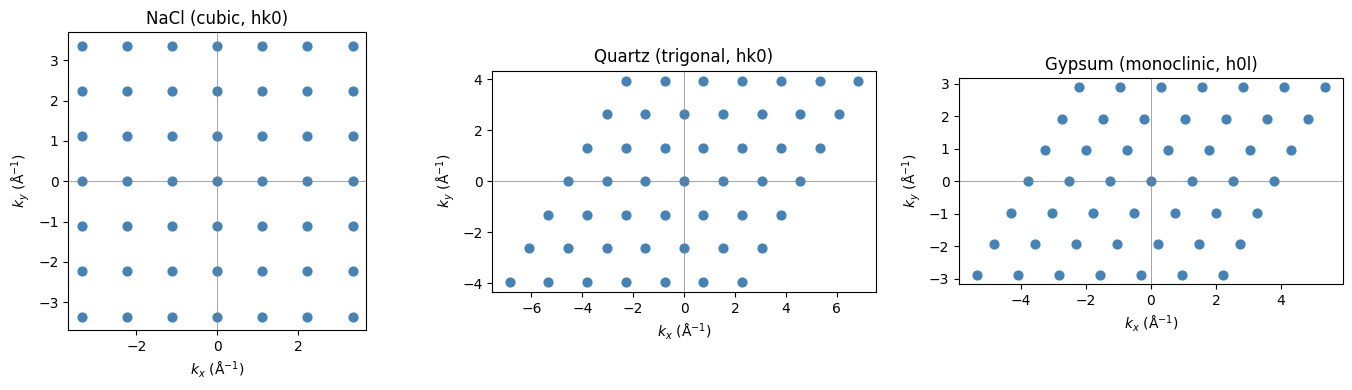

In [15]:
def hk0_points(rl):
    """Cartesian (x, y) coordinates of hk0 reciprocal lattice points."""
    a_star = rl.a_star
    b_star = rl.b_star
    gamma_star_rad = math.radians(rl.gamma_star)
    xs, ys = [], []
    for h in range(-3, 4):
        for k in range(-3, 4):
            x = h * a_star + k * b_star * math.cos(gamma_star_rad)
            y = k * b_star * math.sin(gamma_star_rad)
            xs.append(x)
            ys.append(y)
    return xs, ys


def h0l_points(rl):
    """Cartesian (x, y) coordinates of h0l reciprocal lattice points."""
    a_star = rl.a_star
    c_star = rl.c_star
    beta_star_rad = math.radians(rl.beta_star)
    xs, ys = [], []
    for h in range(-3, 4):
        for ll in range(-3, 4):
            x = h * a_star + ll * c_star * math.cos(beta_star_rad)
            y = ll * c_star * math.sin(beta_star_rad)
            xs.append(x)
            ys.append(y)
    return xs, ys


fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, reciprocal_lattice, title, plot_fn in [
    (axes[0], rl_nacl, "NaCl (cubic, hk0)", hk0_points),
    (axes[1], rl_qz, "Quartz (trigonal, hk0)", hk0_points),
    (axes[2], rl_mono, "Gypsum (monoclinic, h0l)", h0l_points),
]:
    xs, ys = plot_fn(reciprocal_lattice)
    ax.scatter(xs, ys, color="steelblue", s=40)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$k_x$ (Å$^{-1}$)")
    ax.set_ylabel(r"$k_y$ (Å$^{-1}$)")
    ax.set_title(title)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

## Predicted peak positions

Given d-spacings from the reciprocal lattice, Bragg's law gives the
scattering angle for any wavelength. Here we enumerate low-index
reflections and plot where their peaks fall for Cu K-alpha (lambda =
1.5406 Å). This is the connection between the lattice geometry we have
been computing and what appears on a diffractometer.

In [16]:
LAMBDA_CU_KA = 1.5406  # Å


def bragg_peaks(rl, hkl_range=4):
    """Compute unique d-spacings and 2-theta values for all reflections
    within +/- hkl_range."""
    peaks = []
    for h in range(-hkl_range, hkl_range + 1):
        for k in range(-hkl_range, hkl_range + 1):
            for ll in range(-hkl_range, hkl_range + 1):
                if h == 0 and k == 0 and ll == 0:
                    continue
                g = rl.vector([h, k, ll])
                d = 2 * math.pi / g.norm()
                sin_theta = LAMBDA_CU_KA / (2 * d)
                if abs(sin_theta) <= 1:
                    two_theta = 2 * math.degrees(math.asin(sin_theta))
                    peaks.append((h, k, ll, d, two_theta))
    # Deduplicate by 2-theta (symmetry-equivalent reflections)
    seen = set()
    unique = []
    for h, k, ll, d, tt in sorted(peaks, key=lambda x: x[4]):
        tt_rounded = round(tt, 2)
        if tt_rounded not in seen:
            seen.add(tt_rounded)
            unique.append((h, k, ll, d, tt))
    return unique

In [17]:
# Print the first few peaks for NaCl as a sanity check
nacl_peaks = bragg_peaks(rl_nacl)
print("NaCl: first 8 reflections (Cu Kα)")
print(f"{'hkl':>8}  {'d (Å)':>8}  {'2θ (°)':>8}")
for h, k, ll, d, tt in nacl_peaks[:8]:
    print(f"({h}{k}{ll}){d:>10.4f}{tt:>10.2f}")

NaCl: first 8 reflections (Cu Kα)
     hkl     d (Å)    2θ (°)
(-100)    5.6200     15.76
(-1-10)    3.9739     22.35
(-1-11)    3.2447     27.47
(-200)    2.8100     31.82
(-201)    2.5133     35.70
(-21-1)    2.2944     39.23
(-2-20)    1.9870     45.62
(-300)    1.8733     48.56


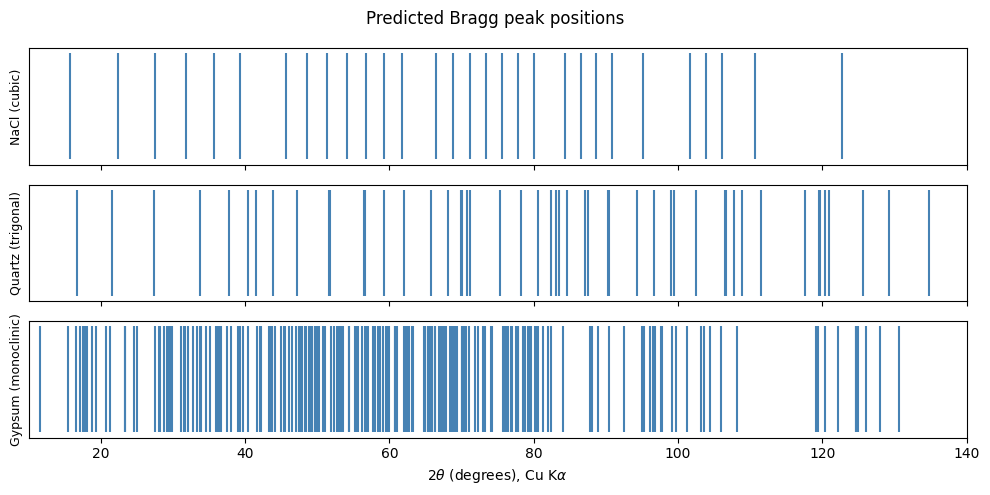

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)

for ax, reciprocal_lattice, label in [
    (axes[0], rl_nacl, "NaCl (cubic)"),
    (axes[1], rl_qz, "Quartz (trigonal)"),
    (axes[2], rl_mono, "Gypsum (monoclinic)"),
]:
    peaks = bragg_peaks(reciprocal_lattice)
    two_thetas = [p[4] for p in peaks]
    ax.vlines(two_thetas, 0, 1, color="steelblue", linewidth=1.5)
    ax.set_ylabel(label, fontsize=9)
    ax.set_yticks([])
    ax.set_xlim(10, 140)

axes[2].set_xlabel(r"2$\theta$ (degrees), Cu K$\alpha$")
fig.suptitle("Predicted Bragg peak positions")
plt.tight_layout()
plt.show()

The cubic pattern has the fewest unique peaks because high symmetry collapses
many reflections to the same d-spacing. As symmetry decreases through trigonal
to monoclinic, peaks split and the pattern grows denser.

## Next steps

This notebook covered lattice geometry and reciprocal space calculations across
three crystal systems. The next notebook (`01_crystal_symmetry`) introduces
space groups, symmetry expansion of atomic positions, and systematic absences.